In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
credit = pd.read_csv("../data/credit_customers.csv")

In [3]:
print(credit['class'].unique())
print(credit['class'].value_counts())
print(repr(credit['class'].iloc[0]))

<StringArray>
['good', 'bad']
Length: 2, dtype: str
class
good    700
bad     300
Name: count, dtype: int64
'good'


In [4]:
print(credit.head())
print("\n \n")
print(credit.info())
print("\n \n")
print(credit.shape)


  checking_status  duration                  credit_history  \
0              <0       6.0  critical/other existing credit   
1        0<=X<200      48.0                   existing paid   
2     no checking      12.0  critical/other existing credit   
3              <0      42.0                   existing paid   
4              <0      24.0              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv         1169.0  no known savings        >=7   
1             radio/tv         5951.0              <100     1<=X<4   
2            education         2096.0              <100     4<=X<7   
3  furniture/equipment         7882.0              <100     4<=X<7   
4              new car         4870.0              <100     1<=X<4   

   installment_commitment     personal_status other_parties  ...  \
0                     4.0         male single          none  ...   
1                     2.0  female div/dep/mar          none  ...

In [5]:
print(credit.describe())
print("\n \n")
print(credit.dtypes)



          duration  credit_amount  installment_commitment  residence_since  \
count  1000.000000    1000.000000             1000.000000      1000.000000   
mean     20.903000    3271.258000                2.973000         2.845000   
std      12.058814    2822.736876                1.118715         1.103718   
min       4.000000     250.000000                1.000000         1.000000   
25%      12.000000    1365.500000                2.000000         2.000000   
50%      18.000000    2319.500000                3.000000         3.000000   
75%      24.000000    3972.250000                4.000000         4.000000   
max      72.000000   18424.000000                4.000000         4.000000   

               age  existing_credits  num_dependents  
count  1000.000000       1000.000000     1000.000000  
mean     35.546000          1.407000        1.155000  
std      11.375469          0.577654        0.362086  
min      19.000000          1.000000        1.000000  
25%      27.000000    

In [6]:
print(credit.columns.tolist())
print("\n \n")
print(credit.isnull().sum())

['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'class']

 

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64


In [7]:
print(credit['class'].value_counts())

class
good    700
bad     300
Name: count, dtype: int64


In [8]:
credit['class'] = credit['class'].map({'good': 0, 'bad': 1})        # good → 0 (no default), bad  → 1 (defaulted), model needs numbers not text
print("After map:", credit['class'].unique())
print(credit['class'].value_counts())

categorical_cols = credit.select_dtypes(include=['object', 'str']).columns.tolist()
"""select_dtypes filters columns by data type
include=['object', 'str'] = text columns only
.columns.tolist() = converts to a Python list
result: ['checking_status', 'credit_history', 'purpose', ...]"""

print(categorical_cols)
if 'class' in categorical_cols:
    categorical_cols.remove('class')
    
"""after map() above, 'class' is now 0/1 numbers
but select_dtypes might still include it
afety check — don't encode the target"""
    
credit_dum = pd.get_dummies(credit, columns=categorical_cols, drop_first=True)

"""same get_dummies from P6
but instead of naming columns manually like ['Sex', 'Embarked']
pass the whole list of text columns
drop_first=True removes one dummy to avoid redundancy"""
 

print(credit_dum['class'].isnull().sum())

credit_dum.head()

After map: [0 1]
class
0    700
1    300
Name: count, dtype: int64
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
0


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,class,checking_status_<0,checking_status_>=200,...,property_magnitude_real estate,other_payment_plans_none,other_payment_plans_stores,housing_own,housing_rent,job_skilled,job_unemp/unskilled non res,job_unskilled resident,own_telephone_yes,foreign_worker_yes
0,6.0,1169.0,4.0,4.0,67.0,2.0,1.0,0,True,False,...,True,True,False,True,False,True,False,False,True,True
1,48.0,5951.0,2.0,2.0,22.0,1.0,1.0,1,False,False,...,True,True,False,True,False,True,False,False,False,True
2,12.0,2096.0,2.0,3.0,49.0,1.0,2.0,0,False,False,...,True,True,False,True,False,False,False,True,False,True
3,42.0,7882.0,2.0,4.0,45.0,1.0,2.0,0,True,False,...,False,True,False,False,False,True,False,False,False,True
4,24.0,4870.0,3.0,4.0,53.0,2.0,2.0,1,True,False,...,False,True,False,False,False,True,False,False,False,True


In [9]:
X = credit_dum.drop(['class'], axis=1)
y = credit_dum['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Logistic Regression 
model_logr =  LogisticRegression()
model_logr.fit(X_train_scaled, y_train)

# Random Forest Classifier
model_rfc = RandomForestClassifier(n_estimators=100, random_state=42)
model_rfc.fit(X_train_scaled, y_train)

#XGBClassifier
model_xbc = XGBClassifier()
model_xbc.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

for name, model in [("Logistic Regression", model_logr),
                     ("Random Forest", model_rfc),
                     ("XGBoost", model_xbc)]:
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
    print(f"\n \n{name}")
    print(f"Accuracy: {acc:.4f} | ROC AUC: {roc:.4f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


 
Logistic Regression
Accuracy: 0.8050 | ROC AUC: 0.8181
[[126  15]
 [ 24  35]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       141
           1       0.70      0.59      0.64        59

    accuracy                           0.81       200
   macro avg       0.77      0.74      0.75       200
weighted avg       0.80      0.81      0.80       200


 
Random Forest
Accuracy: 0.7950 | ROC AUC: 0.8234
[[133   8]
 [ 33  26]]
              precision    recall  f1-score   support

           0       0.80      0.94      0.87       141
           1       0.76      0.44      0.56        59

    accuracy                           0.80       200
   macro avg       0.78      0.69      0.71       200
weighted avg       0.79      0.80      0.78       200


 
XGBoost
Accuracy: 0.7750 | ROC AUC: 0.8205
[[125  16]
 [ 29  30]]
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       141
           1

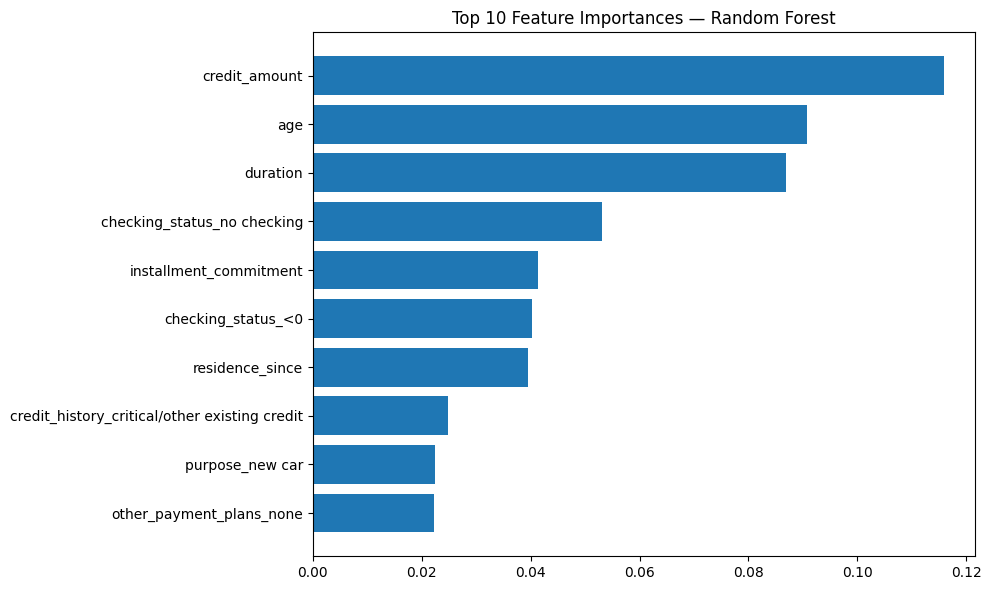

In [11]:
import matplotlib.pyplot as plt
import numpy as np

features = credit_dum.drop('class', axis=1).columns
importance = model_rfc.feature_importances_

indices = np.argsort(importance)[-10:]
plt.figure(figsize=(10, 6))
plt.barh(features[indices], importance[indices])
plt.title("Top 10 Feature Importances — Random Forest")
plt.tight_layout()
plt.savefig("../plots/feature_importance.png")
plt.show()